# Blood Glucose Prediction from 1-Minute HRV Features
## Prediction horizon version: 15-minute / 30-minute CGM forecasting

This notebook uses a different feature engineering strategy from the original notebook:

- extract HRV features from **1-minute IBI windows**
- keep only these features: **HR, SDNN, SDSD, RMSSD, PNNI_20, PNNI_50, HR_MAD, CVNN, CVSD**
- concatenate the **current minute + previous 4 minutes** of HRV features
- use the HRV row at time *t* to predict glucose at *t + 15 min* or *t + 30 min*
- shift the target forward by 3 CGM rows for 15 minutes or 6 CGM rows for 30 minutes

This is closer to a sequence-style representation: each CGM row receives the last 5 minutes of HRV context, and the target is future glucose rather than the current reading.

---
## Method Summary

If a CGM reading occurs at `12:04`, the model input is built from the 1-minute HRV windows ending at `12:00`, `12:01`, `12:02`, `12:03`, and `12:04`.

So the final row looks like this:

- `HR_t`, `SDNN_t`, ...
- `HR_t-1`, `SDNN_t-1`, ...
- `HR_t-2`, `SDNN_t-2`, ...
- `HR_t-3`, `SDNN_t-3`, ...
- `HR_t-4`, `SDNN_t-4`, ...
- `glucose` shifted forward by 3 rows for 15 minutes or 6 rows for 30 minutes

No median imputation is applied to lagged features. Rows that cannot provide the full 5-minute HRV history are dropped. The feature row stays at time *t*; only the target moves into the future.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import neurokit2 as nk
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PARTICIPANT = '001'
BASE_PATH = f'data/bigidea/{PARTICIPANT}/'

print('Libraries loaded successfully')
print(f'neurokit2 version: {nk.__version__}')

Libraries loaded successfully
neurokit2 version: 0.2.13


In [2]:
# Load raw data
ibi_raw = pd.read_csv(BASE_PATH + f'IBI_{PARTICIPANT}.csv')
cgm_raw = pd.read_csv(BASE_PATH + f'Dexcom_{PARTICIPANT}.csv')

print('IBI raw shape:', ibi_raw.shape)
print('CGM raw shape:', cgm_raw.shape)
print('IBI columns:', ibi_raw.columns.tolist())
print('CGM columns:', cgm_raw.columns.tolist())

IBI raw shape: (266366, 2)
CGM raw shape: (2573, 13)
IBI columns: ['datetime', ' ibi']
CGM columns: ['Index', 'Timestamp (YYYY-MM-DDThh:mm:ss)', 'Event Type', 'Event Subtype', 'Patient Info', 'Device Info', 'Source Device ID', 'Glucose Value (mg/dL)', 'Insulin Value (u)', 'Carb Value (grams)', 'Duration (hh:mm:ss)', 'Glucose Rate of Change (mg/dL/min)', 'Transmitter Time (Long Integer)']


In [3]:
# Clean CGM
cgm = cgm_raw[cgm_raw['Event Type'] == 'EGV'].copy()
cgm = cgm.dropna(subset=['Timestamp (YYYY-MM-DDThh:mm:ss)', 'Glucose Value (mg/dL)'])
cgm['datetime'] = pd.to_datetime(cgm['Timestamp (YYYY-MM-DDThh:mm:ss)'])
cgm = cgm[['datetime', 'Glucose Value (mg/dL)']].rename(columns={'Glucose Value (mg/dL)': 'glucose'})
cgm = cgm.sort_values('datetime').reset_index(drop=True)

print(f'CGM shape after cleaning: {cgm.shape}')
print(f'Date range: {cgm["datetime"].min()} -> {cgm["datetime"].max()}')
print(cgm.head())

CGM shape after cleaning: (2561, 2)
Date range: 2020-02-13 17:23:32 -> 2020-02-22 17:53:23
             datetime  glucose
0 2020-02-13 17:23:32     61.0
1 2020-02-13 17:28:32     59.0
2 2020-02-13 17:33:32     58.0
3 2020-02-13 17:38:32     59.0
4 2020-02-13 17:43:31     63.0


In [4]:
# Clean IBI
ibi = ibi_raw.copy()
ibi.columns = ibi.columns.str.strip().str.lower().str.replace(' ', '_')
ibi = ibi.rename(columns={ibi.columns[0]: 'datetime', ibi.columns[1]: 'ibi'})
ibi['datetime'] = pd.to_datetime(ibi['datetime'])
ibi = ibi.sort_values('datetime').reset_index(drop=True)

ibi = ibi[(ibi['ibi'] >= 0.3) & (ibi['ibi'] <= 1.5)].copy()
ibi['ibi_diff_pct'] = ibi['ibi'].pct_change().abs()
ibi = ibi[(ibi['ibi_diff_pct'].isna()) | (ibi['ibi_diff_pct'] <= 0.20)].copy()
ibi = ibi.drop(columns=['ibi_diff_pct']).reset_index(drop=True)

print(f'IBI shape after cleaning: {ibi.shape}')
print(f'Date range: {ibi["datetime"].min()} -> {ibi["datetime"].max()}')
print(ibi.head())

IBI shape after cleaning: (258831, 2)
Date range: 2020-02-13 15:33:22.059328 -> 2020-02-22 17:51:35.691598
                    datetime       ibi
0 2020-02-13 15:33:22.059328  0.828163
1 2020-02-13 15:33:22.934368  0.875040
2 2020-02-13 15:34:21.593303  0.984420
3 2020-02-13 15:34:22.483969  0.890666
4 2020-02-13 15:34:23.421512  0.937543


---
## Minute-Level HRV Extraction

Each 1-minute window is labelled by its **window end time**.
For example, the window `[12:03, 12:04)` is labelled `12:04`.
That makes the alignment to CGM timestamps straightforward.

In [5]:
HRV_BASE_FEATURES = ['HR', 'SDNN', 'SDSD', 'RMSSD', 'PNNI_20', 'PNNI_50', 'HR_MAD', 'CVNN', 'CVSD']

def compute_minute_hrv(ibi_window_seconds, min_beats=10):
    """Compute a compact set of HRV features from a 1-minute IBI window."""
    result = {feature: np.nan for feature in HRV_BASE_FEATURES}
    ibi_arr = np.asarray(ibi_window_seconds, dtype=float)
    ibi_arr = ibi_arr[~np.isnan(ibi_arr)]

    if len(ibi_arr) < min_beats:
        return result

    rri_ms = ibi_arr * 1000.0
    peaks_ms = np.append([0], np.cumsum(rri_ms))

    try:
        hrv_df = nk.hrv_time(peaks_ms, sampling_rate=1000)
        row = hrv_df.iloc[0]

        mean_nn = row['HRV_MeanNN'] if 'HRV_MeanNN' in hrv_df.columns else np.nan
        result['HR'] = 60000.0 / mean_nn if pd.notna(mean_nn) and mean_nn > 0 else np.nan
        result['SDNN'] = row['HRV_SDNN'] if 'HRV_SDNN' in hrv_df.columns else np.nan
        result['SDSD'] = row['HRV_SDSD'] if 'HRV_SDSD' in hrv_df.columns else np.nan
        result['RMSSD'] = row['HRV_RMSSD'] if 'HRV_RMSSD' in hrv_df.columns else np.nan
        result['PNNI_20'] = row['HRV_pNN20'] if 'HRV_pNN20' in hrv_df.columns else np.nan
        result['PNNI_50'] = row['HRV_pNN50'] if 'HRV_pNN50' in hrv_df.columns else np.nan
        result['HR_MAD'] = row['HRV_MadNN'] if 'HRV_MadNN' in hrv_df.columns else np.nan
        result['CVNN'] = row['HRV_CVNN'] if 'HRV_CVNN' in hrv_df.columns else np.nan
        result['CVSD'] = row['HRV_CVSD'] if 'HRV_CVSD' in hrv_df.columns else np.nan
        return result
    except Exception as e:
        print(f"Error computing HRV for window with {len(ibi_arr)} beats: {e}")
        return result


def build_minute_hrv_frame(ibi_df):
    """Build one HRV row per minute, labelled by the minute end timestamp."""
    start = ibi_df['datetime'].min().floor('min') + pd.Timedelta(minutes=1)
    end = ibi_df['datetime'].max().ceil('min')
    minute_ends = pd.date_range(start=start, end=end, freq='1min')

    records = []
    for window_end in minute_ends:
        window_start = window_end - pd.Timedelta(minutes=1)
        mask = (ibi_df['datetime'] >= window_start) & (ibi_df['datetime'] < window_end)
        window_values = ibi_df.loc[mask, 'ibi'].values
        feats = compute_minute_hrv(window_values, min_beats=2)
        feats['datetime'] = window_end
        feats['n_beats'] = len(window_values)
        records.append(feats)

    minute_hrv = pd.DataFrame(records).sort_values('datetime').reset_index(drop=True)
    return minute_hrv

minute_hrv = build_minute_hrv_frame(ibi)
print('Minute HRV shape:', minute_hrv.shape)
print(minute_hrv.tail(10))

Minute HRV shape: (13099, 11)
              HR       SDNN        SDSD       RMSSD    PNNI_20    PNNI_50  \
13089  59.302308  73.706741  101.668093   97.999416  75.000000  25.000000   
13090  63.611552  76.317798  111.090530  106.782175  72.727273  45.454545   
13091  63.220685  61.813613   69.703036   68.011188  57.894737  31.578947   
13092  59.789653  65.729114   80.003195   74.938021  77.777778  55.555556   
13093  62.605821  91.558497  143.637429  123.532163  66.666667  33.333333   
13094        NaN        NaN         NaN         NaN        NaN        NaN   
13095  69.815013  88.392590         NaN  125.006000  50.000000  50.000000   
13096  61.192426  39.064200   86.059572   70.460132  75.000000  50.000000   
13097  62.605821  59.157937  143.637429  101.867063  66.666667  66.666667   
13098  68.324274  43.359760   51.824825   50.633333  40.000000  20.000000   

          HR_MAD      CVNN      CVSD            datetime  n_beats  
13089  34.750661  0.072850  0.096860 2020-02-22 17:43:

---
## Concatenate Current Minute + 4 Lag Minutes

Each HRV feature is expanded into 5 time steps:

- current minute
- lag 1 minute
- lag 2 minutes
- lag 3 minutes
- lag 4 minutes

Only rows with a complete 5-minute HRV history and a matching CGM reading are kept.

In [32]:
def add_lagged_hrv_features(df, feature_cols, n_lags=4):
    df = df.sort_values('datetime').reset_index(drop=True).copy()
    for col in feature_cols:
        for lag in range(1, n_lags + 1):
            df[f'{col}_lag{lag}'] = df[col].shift(lag)
    return df

# --- Add 5-minute rolling stats to minute-level HRV (window=5 minutes) ---
for col in HRV_BASE_FEATURES:
    minute_hrv[f'{col}_roll_mean5'] = minute_hrv[col].rolling(window=5, min_periods=1).mean()
    minute_hrv[f'{col}_roll_std5']  = minute_hrv[col].rolling(window=5, min_periods=1).std()

# --- Time-of-day features ---
seconds_in_day = 24 * 3600
t = minute_hrv['datetime'].dt.hour * 3600 + minute_hrv['datetime'].dt.minute * 60 + minute_hrv['datetime'].dt.second
minute_hrv['time_sin'] = np.sin(2 * np.pi * t / seconds_in_day)
minute_hrv['time_cos'] = np.cos(2 * np.pi * t / seconds_in_day)
minute_hrv['hour'] = minute_hrv['datetime'].dt.hour
minute_hrv['is_night'] = ((minute_hrv['hour'] >= 22) | (minute_hrv['hour'] <= 6)).astype(int)
minute_hrv['is_dawn']  = ((minute_hrv['hour'] >= 4)  & (minute_hrv['hour'] <= 8)).astype(int)

# Create lagged base HRV features (we keep rolling/time features at t only)
lagged_hrv = add_lagged_hrv_features(minute_hrv, HRV_BASE_FEATURES, n_lags=4)
lagged_hrv['hrv_minute'] = lagged_hrv['datetime']
# print('Lagged HRV shape:', lagged_hrv.shape)
# print('Lagged HRV columns:', lagged_hrv.columns.tolist())
# print(lagged_hrv.head(2))
print("Inspect CGM for alignment")
# print(cgm.head())

# --- Lagged differences: HRV_t - HRV_t-lag ---
for col in HRV_BASE_FEATURES:
    for lag in range(1, 5):
        lag_col = f'{col}_lag{lag}'
        diff_col = f'{col}_diff_lag{lag}'
        lagged_hrv[diff_col] = lagged_hrv[col] - lagged_hrv[lag_col]

# --- Build feature column list (base, lags, diffs, rolling, time) ---
feature_cols = []
for col in HRV_BASE_FEATURES:
    feature_cols.append(col)
    for lag in range(1, 5):
        feature_cols.append(f'{col}_lag{lag}')
        feature_cols.append(f'{col}_diff_lag{lag}')
# rolling stats (t only)
for col in HRV_BASE_FEATURES:
    feature_cols.append(f'{col}_roll_mean5')
    feature_cols.append(f'{col}_roll_std5')
# time-of-day features
time_feats = ['time_sin', 'time_cos', 'hour', 'is_night', 'is_dawn']
feature_cols.extend(time_feats)

# Exact datetime matches can fail because CGM and HRV timestamps are not always identical to the second.
# merge_asof aligns each CGM reading to the latest HRV row at or before that timestamp.
cgm_for_merge = cgm.sort_values('datetime').copy()
hrv_for_merge = lagged_hrv.sort_values('datetime').copy()
aligned = pd.merge_asof(
    cgm_for_merge,
    hrv_for_merge,
    on='datetime',
    direction='backward'
)
aligned = aligned.dropna(subset=feature_cols + ['glucose']).copy()
aligned = aligned.sort_values('datetime').reset_index(drop=True)
aligned['alignment_gap_sec'] = (aligned['datetime'] - aligned['hrv_minute']).dt.total_seconds()

print('Aligned dataset shape:', aligned.shape)
print('Feature columns:', len(feature_cols))
print('Alignment gap summary (seconds):')
print(aligned['alignment_gap_sec'].describe())
print('Any HRV minute after CGM time? ', (aligned['alignment_gap_sec'] < 0).any())
print(aligned[['datetime', 'hrv_minute', 'alignment_gap_sec', 'glucose']].tail())

Inspect CGM for alignment
Aligned dataset shape: (974, 109)
Feature columns: 104
Alignment gap summary (seconds):
count    974.000000
mean      27.086242
std        2.693442
min       22.000000
25%       25.000000
50%       27.000000
75%       30.000000
max       33.000000
Name: alignment_gap_sec, dtype: float64
Any HRV minute after CGM time?  False
               datetime          hrv_minute  alignment_gap_sec  glucose
969 2020-02-22 17:18:22 2020-02-22 17:18:00               22.0    132.0
970 2020-02-22 17:23:23 2020-02-22 17:23:00               23.0    134.0
971 2020-02-22 17:28:23 2020-02-22 17:28:00               23.0    137.0
972 2020-02-22 17:33:23 2020-02-22 17:33:00               23.0    139.0
973 2020-02-22 17:38:23 2020-02-22 17:38:00               23.0    141.0


In [33]:
# Prediction horizon setup and verification
CGM_INTERVAL_MINUTES = 5
PREDICTION_HORIZON_MINUTES = 15  # change to 30 for the 30-minute PH
HORIZON_TO_STEPS = {15: 3, 30: 6}

assert PREDICTION_HORIZON_MINUTES in HORIZON_TO_STEPS, 'Use 15 or 30 minutes.'
TARGET_SHIFT_STEPS = HORIZON_TO_STEPS[PREDICTION_HORIZON_MINUTES]

cgm_diffs = cgm['datetime'].sort_values().diff().dropna().dt.total_seconds() / 60
print('CGM spacing summary (minutes):')
print(cgm_diffs.value_counts().sort_index().head(10))
print(f'Median CGM spacing: {cgm_diffs.median():.2f} minutes')
assert np.isclose(cgm_diffs.median(), CGM_INTERVAL_MINUTES, atol=0.1), 'CGM is not 5-minute cadence.'

ph_df = aligned.copy()
ph_df['current_glucose'] = ph_df['glucose']
ph_df['glucose'] = ph_df['glucose'].shift(-TARGET_SHIFT_STEPS)
ph_df['target_datetime'] = ph_df['datetime'].shift(-TARGET_SHIFT_STEPS)
ph_df['actual_horizon_min'] = (ph_df['target_datetime'] - ph_df['datetime']).dt.total_seconds() / 60
ph_df = ph_df[np.isclose(ph_df['actual_horizon_min'], PREDICTION_HORIZON_MINUTES)].copy()
ph_df = ph_df.dropna(subset=['glucose']).copy()
aligned = ph_df.drop(columns=['current_glucose']).copy()

print(f'Prediction horizon: {PREDICTION_HORIZON_MINUTES} minutes')
print(f'Target shift steps  : {TARGET_SHIFT_STEPS}')
print(f'Aligned PH shape    : {aligned.shape}')
print(aligned[['datetime', 'target_datetime', 'actual_horizon_min', 'glucose']].head())

CGM spacing summary (minutes):
datetime
4.966667         1
4.983333       413
5.000000      1737
5.016667       407
10.000000        1
189.983333       1
Name: count, dtype: int64
Median CGM spacing: 5.00 minutes
Prediction horizon: 15 minutes
Target shift steps  : 3
Aligned PH shape    : (430, 111)
              datetime     target_datetime  actual_horizon_min  glucose
8  2020-02-13 18:23:32 2020-02-13 18:38:32                15.0    133.0
24 2020-02-13 21:58:31 2020-02-13 22:13:31                15.0     85.0
25 2020-02-13 22:03:31 2020-02-13 22:18:31                15.0     90.0
29 2020-02-13 22:23:31 2020-02-13 22:38:31                15.0    102.0
30 2020-02-13 22:28:32 2020-02-13 22:43:32                15.0    102.0


---
## Time-Series Train / Validation Split

The split is chronological, not random. That keeps future glucose values out of the training set after the prediction-horizon shift.

In [34]:
TEST_FRACTION = 0.20
split_idx = int(len(aligned) * (1 - TEST_FRACTION))

df_train = aligned.iloc[:split_idx].copy()
df_val = aligned.iloc[split_idx:].copy()

X_train = df_train[feature_cols]
y_train = df_train['glucose']
X_val = df_val[feature_cols]
y_val = df_val['glucose']

print(f'Train rows: {len(X_train)}')
print(f'Val rows  : {len(X_val)}')
print(f'Train range: {df_train["datetime"].min()} -> {df_train["datetime"].max()}')
print(f'Val range  : {df_val["datetime"].min()} -> {df_val["datetime"].max()}')

Train rows: 344
Val rows  : 86
Train range: 2020-02-13 18:23:32 -> 2020-02-20 05:53:25
Val range  : 2020-02-20 18:23:25 -> 2020-02-22 17:23:23


In [35]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    reg_alpha=0.5,
    reg_lambda=1.0,
    eval_metric='rmse',
    early_stopping_rounds=30,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50
)

print('Training complete')
print('Best iteration:', model.best_iteration)
print('Best validation RMSE:', model.best_score)

[0]	validation_0-rmse:15.07667	validation_1-rmse:16.92638
[50]	validation_0-rmse:9.60517	validation_1-rmse:13.19499
[100]	validation_0-rmse:7.71518	validation_1-rmse:13.19832
[113]	validation_0-rmse:7.31126	validation_1-rmse:13.32079
Training complete
Best iteration: 83
Best validation RMSE: 13.149334679004562


In [37]:
def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mard = np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred)) / np.maximum(np.asarray(y_true), 1e-6)) * 100

    print(f'\n{label}')
    print(f'MAE  : {mae:.3f} mg/dL')
    print(f'RMSE : {rmse:.3f} mg/dL')
    print(f'R^2  : {r2:.4f}')
    print(f'MARD : {mard:.2f}%')

    return {'mae': mae, 'rmse': rmse, 'r2': r2, 'mard': mard}

y_pred_train = model.predict(X_train)
y_pred_val = model.predict(X_val)

train_metrics = evaluate(y_train, y_pred_train, f'TRAIN - Participant {PARTICIPANT}')
val_metrics = evaluate(y_val, y_pred_val, f'VALIDATION - Participant {PARTICIPANT}')


TRAIN - Participant 001
MAE  : 6.833 mg/dL
RMSE : 8.300 mg/dL
R^2  : 0.7083
MARD : 6.59%

VALIDATION - Participant 001
MAE  : 9.359 mg/dL
RMSE : 13.149 mg/dL
R^2  : 0.1825
MARD : 7.46%


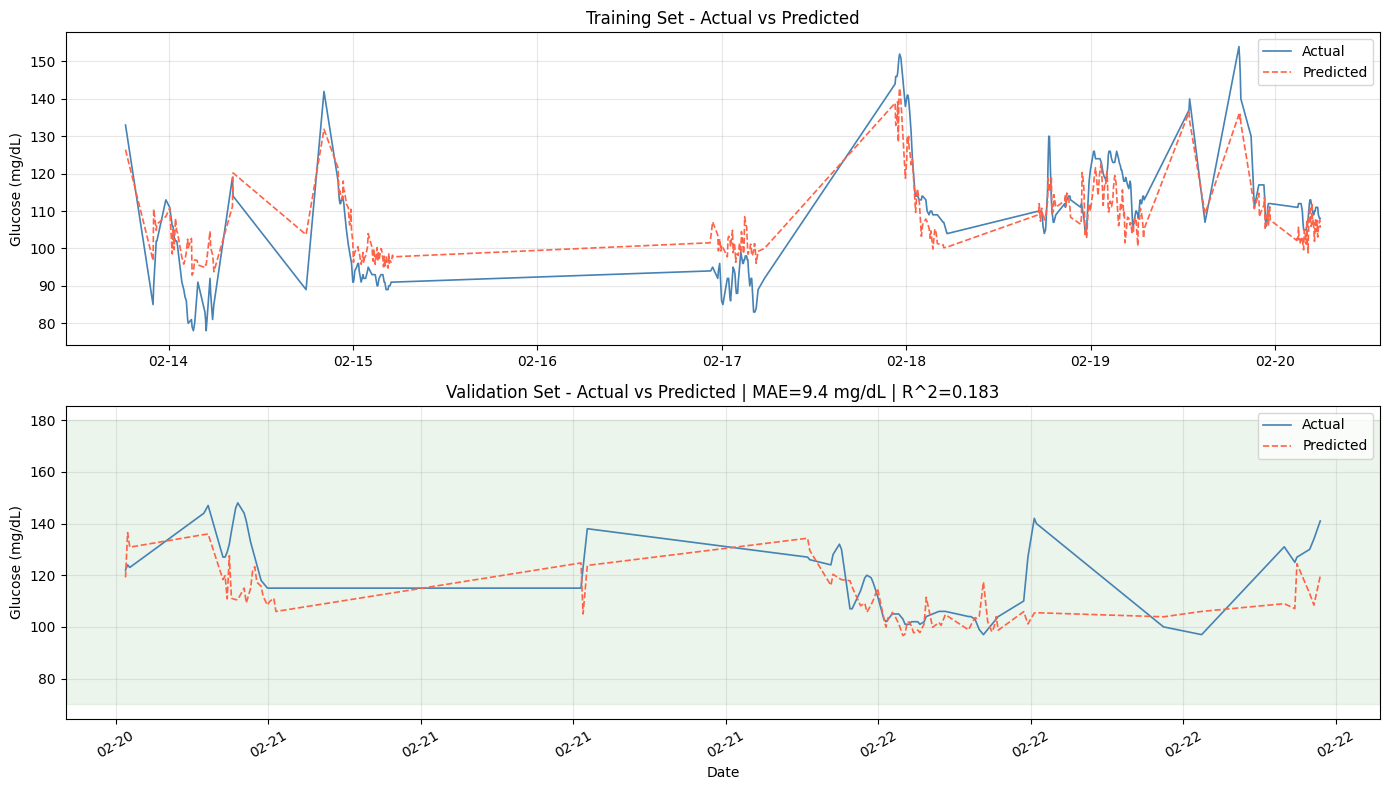

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

axes[0].plot(df_train['datetime'], y_train.values, label='Actual', color='steelblue', linewidth=1.2)
axes[0].plot(df_train['datetime'], y_pred_train, label='Predicted', color='tomato', linewidth=1.2, linestyle='--')
axes[0].set_title('Training Set - Actual vs Predicted')
axes[0].set_ylabel('Glucose (mg/dL)')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

axes[1].plot(df_val['datetime'], y_val.values, label='Actual', color='steelblue', linewidth=1.2)
axes[1].plot(df_val['datetime'], y_pred_val, label='Predicted', color='tomato', linewidth=1.2, linestyle='--')
axes[1].axhspan(70, 180, alpha=0.08, color='green')
axes[1].set_title(f'Validation Set - Actual vs Predicted | MAE={val_metrics["mae"]:.1f} mg/dL | R^2={val_metrics["r2"]:.3f}')
axes[1].set_ylabel('Glucose (mg/dL)')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Top 15 features:
     feature  importance
     HR_lag3    0.071242
   SDSD_lag2    0.057112
   SDSD_lag1    0.050557
       RMSSD    0.047840
     HR_lag1    0.041508
          HR    0.041274
PNNI_50_lag1    0.031473
     HR_lag2    0.030460
   SDSD_lag3    0.028019
   SDNN_lag3    0.027124
   CVSD_lag1    0.026967
 HR_MAD_lag1    0.022104
  RMSSD_lag1    0.021478
   CVSD_lag3    0.021068
 HR_MAD_lag4    0.020345


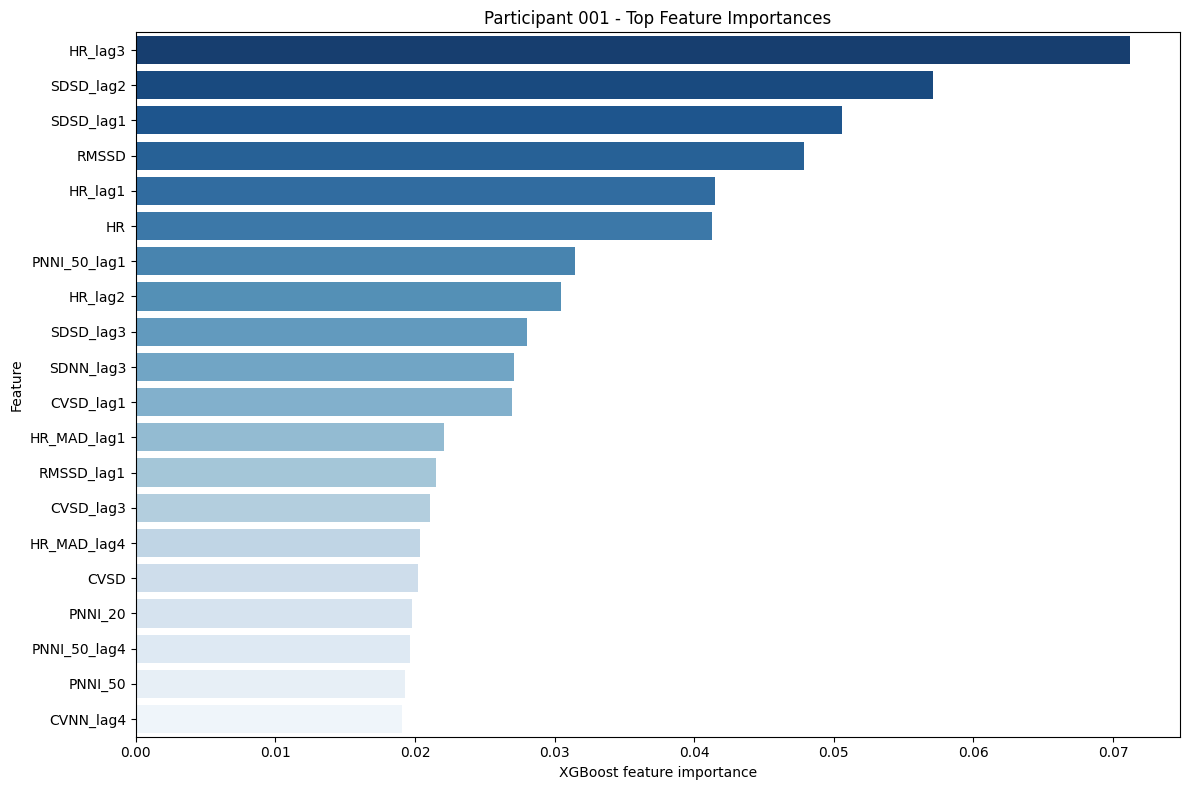

In [13]:
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print('Top 15 features:')
print(importance_df.head(15).to_string(index=False))

plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df.head(20), x='importance', y='feature', palette='Blues_r')
plt.title(f'Participant {PARTICIPANT} - Top Feature Importances')
plt.xlabel('XGBoost feature importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()